In [1]:
# DataCo Supply Chain Data Profiling

# Author:
# Pulkit

# Purpose

# This notebook investigates the quality, completeness,
# structure and business readiness of the supplied datasets.

# No transformations are performed.

# This notebook is purely an investigation.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv(r"C:\Users\Pallav\supply chain end to end project\DataCoSupplyChainDataset.csv" , encoding = "latin1")
dictionary = pd.read_csv(r"C:\Users\Pallav\supply chain end to end project\DescriptionDataCoSupplyChain.csv",encoding = "latin1")
clickstreams = pd.read_csv(r"C:\Users\Pallav\supply chain end to end project\tokenized_access_logs.csv",encoding = "latin1")

In [5]:
# Dataset Overview

# This section identifies the datasets received
# from DataCo Global.

orders.shape

(180519, 53)

In [6]:
dictionary.shape

(52, 2)

In [ ]:
clickstreams.shape

(469977, 8)

In [8]:
# Dataset Preview
orders.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [9]:
dictionary.head()

,FIELDS,DESCRIPTION
0,Type,: Type of transaction made
1,Days for shipping (real),: Actual shipping days of the purchased product
2,Days for shipment (scheduled),: Days of scheduled delivery of the purchased...
3,Benefit per order,: Earnings per order placed
4,Sales per customer,: Total sales per customer made per customer


In [ ]:
clickstreams.head()

,Product,Category,Date,Month,Hour,Department,ip,url
0,adidas Brazuca 2017 Official Match Ball,baseball & softball,9/1/2017 6:00,Sep,6,fitness,37.97.182.65,/department/fitness/category/baseball%20&%20so...
1,The North Face Women's Recon Backpack,hunting & shooting,9/1/2017 6:00,Sep,6,fan shop,206.56.112.1,/department/fan%20shop/category/hunting%20&%20...
2,adidas Kids' RG III Mid Football Cleat,featured shops,9/1/2017 6:00,Sep,6,apparel,215.143.180.0,/department/apparel/category/featured%20shops/...
3,Under Armour Men's Compression EV SL Slide,electronics,9/1/2017 6:00,Sep,6,footwear,206.56.112.1,/department/footwear/category/electronics/prod...
4,Pelican Sunstream 100 Kayak,water sports,9/1/2017 6:01,Sep,6,fan shop,136.108.56.242,/department/fan%20shop/category/water%20sports...


In [10]:
# Dataset Information
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [11]:
dictionary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   FIELDS       52 non-null     object
 1   DESCRIPTION  52 non-null     object
dtypes: object(2)
memory usage: 964.0+ bytes


In [12]:
clickstreams.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 469977 entries, 0 to 469976
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Product     469977 non-null  object
 1   Category    469977 non-null  object
 2   Date        469977 non-null  object
 3   Month       469977 non-null  object
 4   Hour        469977 non-null  int64 
 5   Department  469977 non-null  object
 6   ip          469977 non-null  object
 7   url         469977 non-null  object
dtypes: int64(1), object(7)
memory usage: 28.7+ MB


In [14]:
# Missing Values Investigation
orders.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [15]:
orders.isnull().mean()*100

Type                               0.000000
Days for shipping (real)           0.000000
Days for shipment (scheduled)      0.000000
Benefit per order                  0.000000
Sales per customer                 0.000000
Delivery Status                    0.000000
Late_delivery_risk                 0.000000
Category Id                        0.000000
Category Name                      0.000000
Customer City                      0.000000
Customer Country                   0.000000
Customer Email                     0.000000
Customer Fname                     0.000000
Customer Id                        0.000000
Customer Lname                     0.004432
Customer Password                  0.000000
Customer Segment                   0.000000
Customer State                     0.000000
Customer Street                    0.000000
Customer Zipcode                   0.001662
Department Id                      0.000000
Department Name                    0.000000
Latitude                        

In [16]:
clickstreams.isnull().sum()

Product       0
Category      0
Date          0
Month         0
Hour          0
Department    0
ip            0
url           0
dtype: int64

In [17]:
clickstreams.isnull().mean()*100

Product       0.0
Category      0.0
Date          0.0
Month         0.0
Hour          0.0
Department    0.0
ip            0.0
url           0.0
dtype: float64

In [18]:
# Duplicate Investigation
orders.duplicated().sum()

np.int64(0)

In [19]:
orders["Order Id"].duplicated().sum()

np.int64(114767)

In [20]:
orders["Customer Id"].duplicated().sum()

np.int64(159867)

In [21]:
# Data Types Investigation
orders.dtypes

Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market          

In [22]:
# Numerical Summary
orders.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [23]:
# Categorical Summary
orders.select_dtypes(include = "object").columns

Index(['Type', 'Delivery Status', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Department Name', 'Market',
       'Order City', 'Order Country', 'order date (DateOrders)',
       'Order Region', 'Order State', 'Order Status', 'Product Image',
       'Product Name', 'shipping date (DateOrders)', 'Shipping Mode'],
      dtype='object')

In [24]:
orders["Order Status"].value_counts()

Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

In [25]:
orders["Order Status"].value_counts(normalize = True)*100

Order Status
COMPLETE           32.955534
PENDING_PAYMENT    22.065267
PROCESSING         12.132795
PENDING            11.204915
CLOSED             10.866446
ON_HOLD             5.431007
SUSPECTED_FRAUD     2.250179
CANCELED            2.045214
PAYMENT_REVIEW      1.048643
Name: proportion, dtype: float64

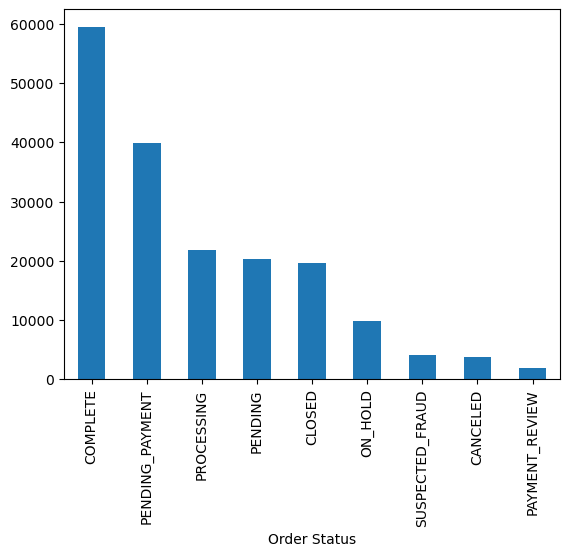

In [26]:
orders["Order Status"].value_counts().plot(kind="bar")
plt.show()

In [ ]:
# Observation

# Complete is the most common order status, accounting for 32.96% of all orders, followed by Pending Payment (22.07%), Processing (12.14%), Pending (11.21%), Closed (10.87%), On Hold (5.43%), Suspected Fraud (2.25%), Canceled (2.05%), and Payment Review (1.05%).

# Insight

# The distribution indicates that most orders are successfully completed, while a smaller proportion remains in various intermediate or exceptional states such as pending, processing, canceled, or under review.
#     This suggests that the majority of orders progress through the order lifecycle successfully.

In [27]:
orders["Type"].value_counts()

Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

In [28]:
orders["Type"].value_counts(normalize = True)*100

Type
DEBIT       38.386541
TRANSFER    27.633102
PAYMENT     23.113910
CASH        10.866446
Name: proportion, dtype: float64

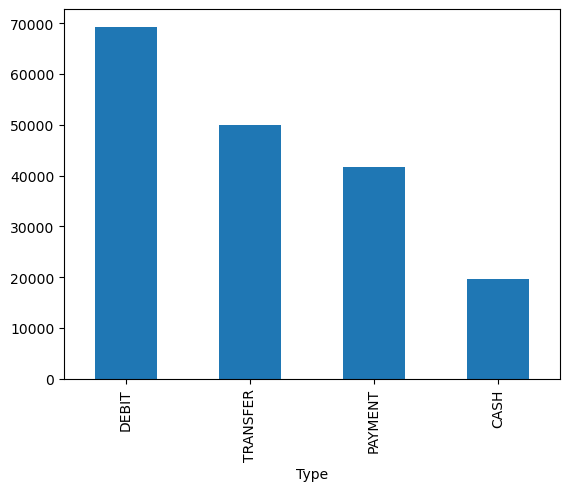

In [29]:
orders["Type"].value_counts().plot(kind = "bar")
plt.show()

In [ ]:
# Observation

# Debit is the most common payment method (38.39%), followed by Transfer (27.63%), Payment (23.11%), and Cash (10.87%).

# Insight

# The distribution indicates that digital payment methods dominate customer transactions, while cash payments account for a relatively small share.

In [30]:
orders["Delivery Status"].value_counts()

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

In [31]:
orders["Delivery Status"].value_counts(normalize = True)*100

Delivery Status
Late delivery        54.829132
Advance shipping     23.040234
Shipping on time     17.835242
Shipping canceled     4.295393
Name: proportion, dtype: float64

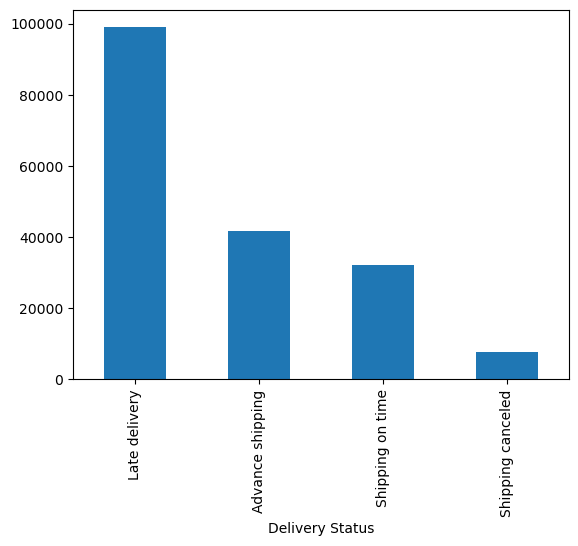

In [32]:
orders["Delivery Status"].value_counts().plot(kind = "bar")
plt.show()

In [ ]:
# Observation

# Late delivery is the most common delivery outcome, accounting for 54.83% of all shipments.
# Advance shipping represents 23.04%, while only 17.84% of orders are delivered on time. 
#     Shipping cancellations account for 4.30% of total orders.

# Business Insight

# The high proportion of late deliveries indicates a significant logistics and fulfillment challenge that could negatively affect customer satisfaction, retention, and operational costs.
#     Although nearly one-quarter of shipments are delivered ahead of schedule, the low percentage of on-time deliveries suggests inconsistent supply chain performance.
#     Further analysis should identify whether delivery delays vary by shipping mode, market, region, product category, or customer segment to uncover the root causes and prioritize operational improvements.

In [33]:
orders["Customer Segment"].value_counts()

Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

In [34]:
orders["Customer Segment"].value_counts(normalize=True)*100

Customer Segment
Consumer       51.797318
Corporate      30.350822
Home Office    17.851860
Name: proportion, dtype: float64

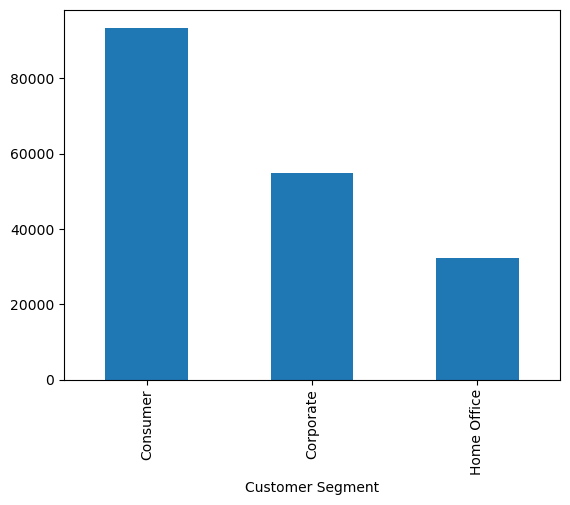

In [35]:
orders["Customer Segment"].value_counts().plot(kind="bar")
plt.show()

In [ ]:
# Observation

# Consumer is the largest customer segment, accounting for 51.80% of all customers, followed by Corporate (30.35%) and Home Office (17.85%).

# Insight

# The distribution indicates that the business primarily serves individual consumers, while corporate and home office customers represent a smaller but notable share of the customer base.
#     This suggests that consumer purchases form the largest portion of overall business activity.

In [36]:
orders["Department Name"].value_counts()

Department Name
Fan Shop              66861
Apparel               48998
Golf                  33220
Footwear              14525
Outdoors               9686
Fitness                2479
Discs Shop             2026
Technology             1465
Pet Shop                492
Book Shop               405
Health and Beauty       362
Name: count, dtype: int64

In [37]:
orders["Department Name"].value_counts(normalize=True)*100

Department Name
Fan Shop              37.038207
Apparel               27.142849
Golf                  18.402495
Footwear               8.046244
Outdoors               5.365640
Fitness                1.373263
Discs Shop             1.122320
Technology             0.811549
Pet Shop               0.272547
Book Shop              0.224353
Health and Beauty      0.200533
Name: proportion, dtype: float64

<Axes: xlabel='Department Name'>

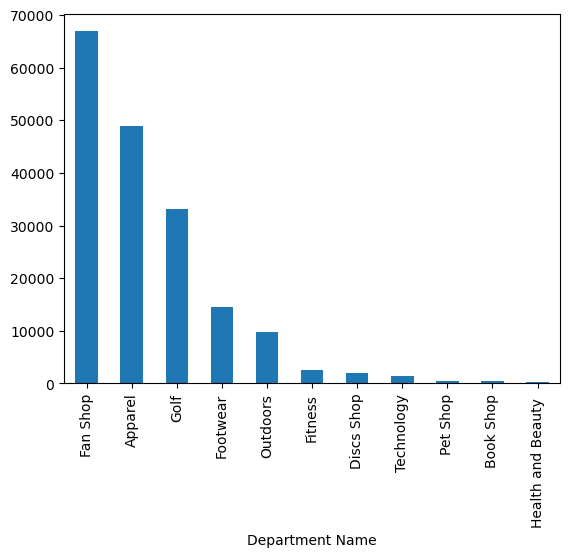

In [38]:
orders["Department Name"].value_counts().plot(kind="bar")

In [ ]:
# Observation

# Fan Shop is the largest department, accounting for 37.04% of all order records, followed by Apparel (27.14%) and Golf (18.40%). The remaining departments each contribute less than 10%, with Health and Beauty (0.20%) representing the smallest share.

# Insight

# The distribution suggests that business activity is concentrated within a few major departments, particularly Fan Shop, Apparel, and Golf, while the remaining departments contribute relatively smaller portions of total orders. 
#     This indicates that a limited number of departments account for the majority of transactions in the dataset.

In [39]:
orders["Category Name"].value_counts()

Category Name
Cleats                  24551
Men's Footwear          22246
Women's Apparel         21035
Indoor/Outdoor Games    19298
Fishing                 17325
Water Sports            15540
Camping & Hiking        13729
Cardio Equipment        12487
Shop By Sport           10984
Electronics              3156
Accessories              1780
Golf Balls               1475
Girls' Apparel           1201
Golf Gloves              1070
Trade-In                  974
Video Games               838
Children's Clothing       652
Women's Clothing          650
Baseball & Softball       632
Hockey                    614
Cameras                   592
Toys                      529
Golf Shoes                524
Pet Supplies              492
Garden                    484
Crafts                    484
DVDs                      483
Computers                 442
Golf Apparel              441
Hunting & Shooting        440
Music                     434
Consumer Electronics      431
Boxing & MMA              

In [40]:
orders["Category Name"].value_counts(normalize = True)*100

Category Name
Cleats                  13.600230
Men's Footwear          12.323357
Women's Apparel         11.652513
Indoor/Outdoor Games    10.690287
Fishing                  9.597328
Water Sports             8.608512
Camping & Hiking         7.605294
Cardio Equipment         6.917277
Shop By Sport            6.084678
Electronics              1.748292
Accessories              0.986046
Golf Balls               0.817089
Girls' Apparel           0.665304
Golf Gloves              0.592735
Trade-In                 0.539555
Video Games              0.464217
Children's Clothing      0.361181
Women's Clothing         0.360073
Baseball & Softball      0.350102
Hockey                   0.340130
Cameras                  0.327943
Toys                     0.293044
Golf Shoes               0.290274
Pet Supplies             0.272547
Garden                   0.268116
Crafts                   0.268116
DVDs                     0.267562
Computers                0.244850
Golf Apparel             0.244296


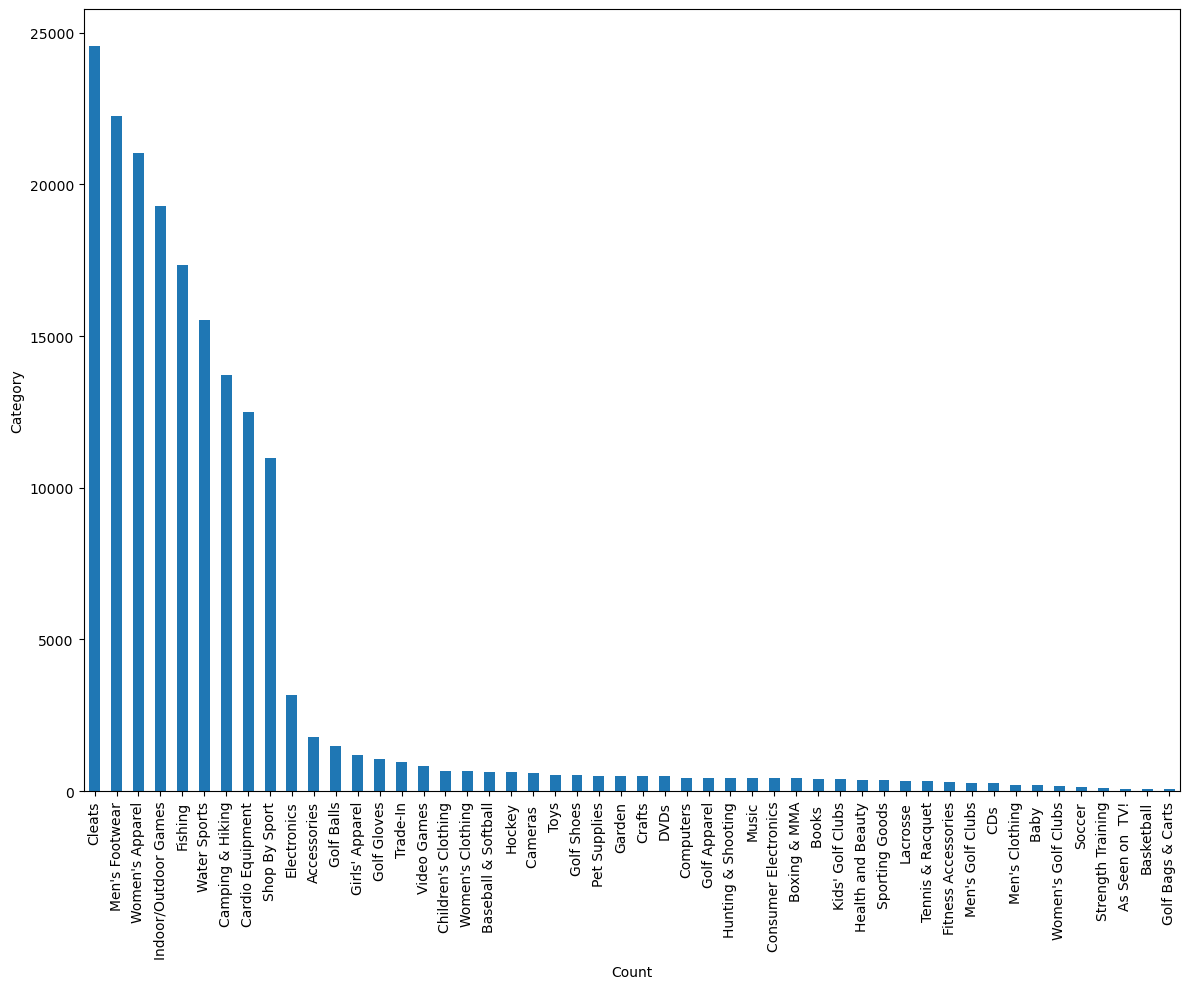

In [41]:
orders["Category Name"].value_counts().plot(kind="bar", figsize=(12,10))
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()

In [ ]:
# Observation

# The dataset contains 50 distinct product categories.
# Cleats is the largest category, accounting for 13.60% of all order records, followed by Men's Footwear (12.32%), Women's Apparel (11.65%),
# Indoor/Outdoor Games (10.69%), and Fishing (9.60%). Together, the leading categories represent a substantial share of the dataset, 
# while many remaining categories each contribute less than 1% of total orders.

# Insight

# The distribution suggests that customer orders are concentrated in a relatively small number of product categories,
# whereas numerous other categories contribute only a small proportion of overall transactions. 
# This indicates an uneven distribution of product demand across the available product categories.

In [42]:
orders["Market"].value_counts()

Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64

In [43]:
orders["Market"].value_counts(normalize = True)*100

Market
LATAM           28.580925
Europe          27.837513
Pacific Asia    22.856320
USCA            14.291570
Africa           6.433672
Name: proportion, dtype: float64

<Axes: xlabel='Market'>

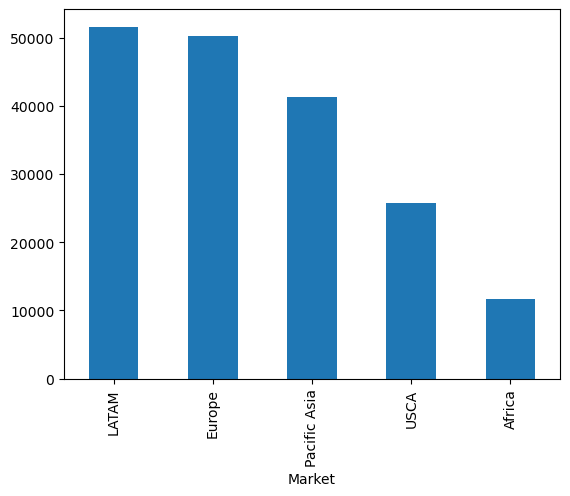

In [44]:
orders["Market"].value_counts().plot(kind="bar")

In [ ]:
# Observation

# LATAM is the largest market, accounting for 28.59% of all order records,
# followed closely by Europe (27.85%) and Pacific Asia (22.87%). USCA contributes 14.30%,
# while Africa represents the smallest market with 6.44% of total orders.

# Insight

# The distribution suggests that business operations are spread across multiple global markets,
# with LATAM, Europe, and Pacific Asia accounting for the majority of order activity. 
# This indicates that the company has a broad international presence, although transaction volumes vary across different markets.

In [45]:
orders["Order Region"].value_counts()

Order Region
Central America    28341
Western Europe     27109
South America      14935
Oceania            10148
Northern Europe     9792
Southeast Asia      9539
Southern Europe     9431
Caribbean           8318
West of USA         7993
South Asia          7731
Eastern Asia        7280
East of USA         6915
West Asia           6009
US Center           5887
South of  USA       4045
Eastern Europe      3920
West Africa         3696
North Africa        3232
East Africa         1852
Central Africa      1677
Southern Africa     1157
Canada               959
Central Asia         553
Name: count, dtype: int64

In [46]:
orders["Order Region"].value_counts(normalize = True)*100

Order Region
Central America    15.699732
Western Europe     15.017256
South America       8.273367
Oceania             5.621569
Northern Europe     5.424360
Southeast Asia      5.284208
Southern Europe     5.224381
Caribbean           4.607825
West of USA         4.427789
South Asia          4.282652
Eastern Asia        4.032816
East of USA         3.830622
West Asia           3.328735
US Center           3.261153
South of  USA       2.240761
Eastern Europe      2.171517
West Africa         2.047430
North Africa        1.790393
East Africa         1.025931
Central Africa      0.928988
Southern Africa     0.640930
Canada              0.531246
Central Asia        0.306339
Name: proportion, dtype: float64

<Axes: xlabel='Order Region'>

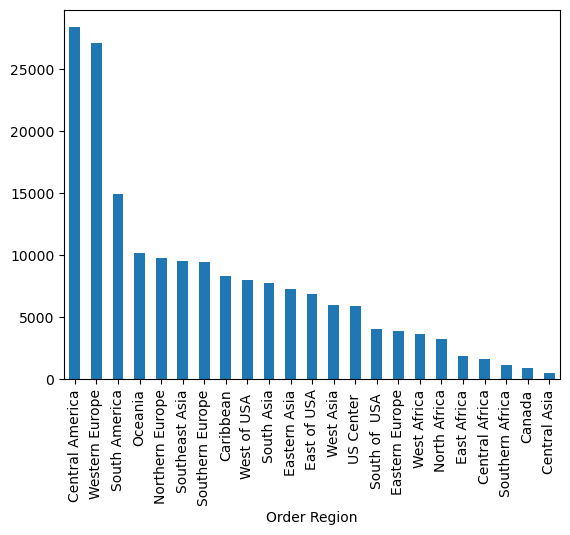

In [47]:
orders["Order Region"].value_counts().plot(kind ="bar")

In [ ]:
# Observation

# Central America represents the largest share of orders, accounting for 15.70% of all records, 
# closely followed by Western Europe (15.02%). South America (8.27%), Oceania (5.62%), Northern Europe (5.42%),
# Southeast Asia (5.28%), and Southern Europe (5.22%) also contribute notable portions.
# The remaining regions individually account for less than 5%, with Central Asia (0.31%) having the smallest share.

# Insight

# The distribution indicates that orders are spread across multiple global regions, 
# with Central America and Western Europe contributing the highest proportions.
# Although business activity is geographically diverse, a relatively small group of regions accounts for a substantial share of total orders,
# while the remaining regions contribute comparatively smaller volumes.

In [48]:
orders["Shipping Mode"].value_counts()

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

In [49]:
orders["Shipping Mode"].value_counts(normalize = True)*100

Shipping Mode
Standard Class    59.690116
Second Class      19.508196
First Class       15.407796
Same Day           5.393892
Name: proportion, dtype: float64

<Axes: xlabel='Shipping Mode'>

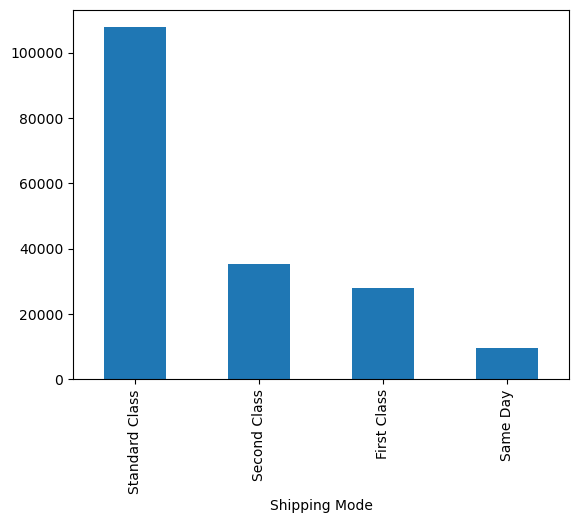

In [50]:
orders["Shipping Mode"].value_counts().plot(kind= "bar")

In [ ]:
# Observation

# Standard Class is the most frequently used shipping mode, accounting for 59.69% of all orders,
# followed by Second Class (19.51%), First Class (15.41%), and Same Day (5.39%), 
# which represents the smallest share.

# Insight

# The distribution suggests that the majority of orders are shipped using Standard Class, 
# while expedited shipping options such as First Class and Same Day are used less frequently.
# This indicates that standard shipping is the primary fulfillment method represented in the dataset.

In [60]:
# Business Domain Profiling.


# 1. Customer Investigation

## Investigation Question

# Which customer fields are useful for analysis, and which fields should be excluded because they are sensitive, redundant, or low-value?

# ## Why This Matters

# Customer fields help analyze performance by customer segment and geography. 
# However, the dataset also contains personal fields such as names, email, street address, and password.
# These fields should be identified early so they are not used in downstream dashboards or reports.
    
customer_cols = [
    "Customer Id",
    "Customer Segment",
    "Customer City",
    "Customer State",
    "Customer Country",
    "Customer Email",
    "Customer Fname",
    "Customer Lname",
    "Customer Password",
    "Customer Street"
]

orders[customer_cols].head()

# Reasoning:
# We isolate customer fields so the investigation stays focused only on customer-related data.

,Customer Id,Customer Segment,Customer City,Customer State,Customer Country,Customer Email,Customer Fname,Customer Lname,Customer Password,Customer Street
0,20755,Consumer,Caguas,PR,Puerto Rico,XXXXXXXXX,Cally,Holloway,XXXXXXXXX,5365 Noble Nectar Island
1,19492,Consumer,Caguas,PR,Puerto Rico,XXXXXXXXX,Irene,Luna,XXXXXXXXX,2679 Rustic Loop
2,19491,Consumer,San Jose,CA,EE. UU.,XXXXXXXXX,Gillian,Maldonado,XXXXXXXXX,8510 Round Bear Gate
3,19490,Home Office,Los Angeles,CA,EE. UU.,XXXXXXXXX,Tana,Tate,XXXXXXXXX,3200 Amber Bend
4,19489,Corporate,Caguas,PR,Puerto Rico,XXXXXXXXX,Orli,Hendricks,XXXXXXXXX,8671 Iron Anchor Corners


In [61]:
# Inspect structure
orders[customer_cols].info()
### Output Interpretation

# This check shows the data type and non-null count for each customer field.
# It helps identify whether customer fields are complete and whether any fields need type correction later.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Customer Id        180519 non-null  int64 
 1   Customer Segment   180519 non-null  object
 2   Customer City      180519 non-null  object
 3   Customer State     180519 non-null  object
 4   Customer Country   180519 non-null  object
 5   Customer Email     180519 non-null  object
 6   Customer Fname     180519 non-null  object
 7   Customer Lname     180511 non-null  object
 8   Customer Password  180519 non-null  object
 9   Customer Street    180519 non-null  object
dtypes: int64(1), object(9)
memory usage: 13.8+ MB


In [62]:
# Missing value check

customer_missing = orders[customer_cols].isnull().sum().to_frame("missing_count")
customer_missing["missing_pct"] = (orders[customer_cols].isnull().mean() * 100).round(2)

customer_missing

### Output Interpretation

# Missing values in customer fields may affect segmentation, geographic analysis,
# and customer-level aggregation. Fields with high missing percentages should be reviewed during the cleaning phase.

,missing_count,missing_pct
Customer Id,0,0.0
Customer Segment,0,0.0
Customer City,0,0.0
Customer State,0,0.0
Customer Country,0,0.0
Customer Email,0,0.0
Customer Fname,0,0.0
Customer Lname,8,0.0
Customer Password,0,0.0
Customer Street,0,0.0


In [64]:
# Unique customer count

total_rows = orders.shape[0]
unique_customers = orders["Customer Id"].nunique()

total_rows, unique_customers

### Output Interpretation

# The total row count represents order-line records, while the unique customer count represents distinct customers. 
# If the number of rows is much larger than the number of customers, it confirms that customers appear multiple times across transactions.

(180519, 20652)

In [65]:
# Duplicate customer IDs
orders["Customer Id"].duplicated().sum()

### Output Interpretation

# Duplicate Customer Id values are expected in this dataset because one customer can place multiple orders or appear across multiple order items.
# This is not automatically a data quality issue.

np.int64(159867)

In [66]:
# Customer segment distribution
segment_counts = orders["Customer Segment"].value_counts()
segment_pct = (orders["Customer Segment"].value_counts(normalize=True) * 100).round(2)

segment_summary = pd.DataFrame({
    "count": segment_counts,
    "percentage": segment_pct
})

segment_summary

,count,percentage
Customer Segment,,
Consumer,93504,51.80
Corporate,54789,30.35
Home Office,32226,17.85


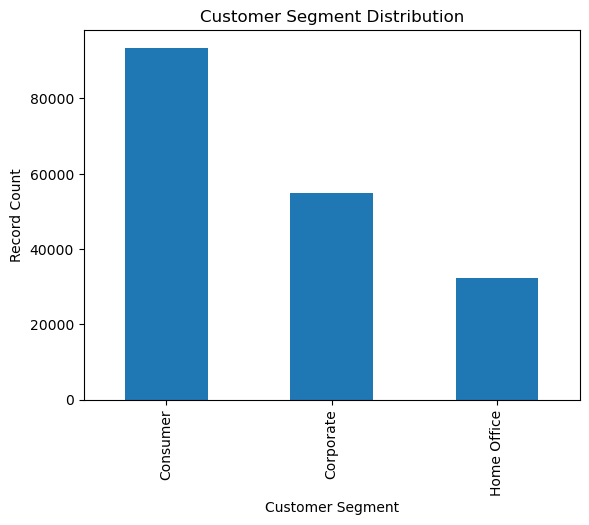

In [67]:
segment_counts.plot(kind="bar", title="Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Record Count")
plt.show()

In [ ]:
# ### Output Interpretation

# Customer Segment shows how transaction records are distributed across Consumer, Corporate, and Home Office customers.
# This field will be useful later for comparing late delivery rate, sales, and profitability across customer groups.

In [68]:
# Customer geography distribution
orders["Customer Country"].value_counts()

Customer Country
EE. UU.        111146
Puerto Rico     69373
Name: count, dtype: int64

In [70]:
(orders["Customer Country"].value_counts(normalize=True) * 100).round(2)

Customer Country
EE. UU.        61.57
Puerto Rico    38.43
Name: proportion, dtype: float64

In [71]:
orders[["Customer City", "Customer State", "Customer Country"]].nunique()

Customer City       563
Customer State       46
Customer Country      2
dtype: int64

In [ ]:
# ### Output Interpretation

# Customer geography fields show where customers are located. Country has lower cardinality, while City and State usually have higher cardinality. 
# These fields may be useful for geographic analysis, but they may require standardization before reporting.

In [72]:
# Sensitive field review
sensitive_cols = [
    "Customer Email",
    "Customer Fname",
    "Customer Lname",
    "Customer Password",
    "Customer Street"
]

orders[sensitive_cols].isnull().sum()
### Output Interpretation

# These fields contain personal or sensitive customer information. They are not required for business-level analytics and should be excluded from dashboards,
# public reports, and final analytical datasets unless there is a specific approved use case.

Customer Email       0
Customer Fname       0
Customer Lname       8
Customer Password    0
Customer Street      0
dtype: int64

In [73]:
# Analytical usefulness classification
customer_usefulness = pd.DataFrame({
    "Column": customer_cols,
    "Analytical Usefulness": [
        "High",
        "High",
        "Medium",
        "Medium",
        "Medium",
        "Low",
        "Low",
        "Low",
        "Exclude",
        "Low"
    ],
    "Reason": [
        "Customer identifier used for aggregation and customer-level analysis.",
        "Useful for segmentation analysis.",
        "Useful for geographic analysis.",
        "Useful for geographic analysis.",
        "Useful for country-level analysis.",
        "Sensitive personal field; not required for dashboards.",
        "Sensitive personal field; not required for dashboards.",
        "Sensitive personal field; not required for dashboards.",
        "Sensitive credential field; exclude from analytics.",
        "Sensitive address field; not required for dashboards."
    ]
})

customer_usefulness

,Column,Analytical Usefulness,Reason
0,Customer Id,High,Customer identifier used for aggregation and c...
1,Customer Segment,High,Useful for segmentation analysis.
2,Customer City,Medium,Useful for geographic analysis.
3,Customer State,Medium,Useful for geographic analysis.
4,Customer Country,Medium,Useful for country-level analysis.
5,Customer Email,Low,Sensitive personal field; not required for das...
6,Customer Fname,Low,Sensitive personal field; not required for das...
7,Customer Lname,Low,Sensitive personal field; not required for das...
8,Customer Password,Exclude,Sensitive credential field; exclude from analy...
9,Customer Street,Low,Sensitive address field; not required for dash...


In [ ]:
# ### Customer Investigation Summary

# The customer domain contains fields with different levels of analytical value.

# High-value fields:
# - Customer Id
# - Customer Segment

# Medium-value fields:
# - Customer City
# - Customer State
# - Customer Country

# Fields to exclude from downstream dashboards:
# - Customer Email
# - Customer Fname
# - Customer Lname
# - Customer Password
# - Customer Street

# Customer Id is expected to repeat because the dataset is recorded at the order-line level.
# Customer Segment and geography fields should be retained for later analysis of delivery performance, sales performance, and customer distribution.

In [ ]:
# # 2. Order & Fulfillment Investigation

# ## Investigation Question

# How does the order fulfillment process operate, and what operational insights can be extracted from order lifecycle, delivery performance, shipping methods, and payment transactions?

# ## Why This Matters

# The order fulfillment process directly impacts customer satisfaction, operational efficiency, and business profitability.
# Investigating these fields helps identify delivery delays, operational bottlenecks, payment behavior,
# and shipping performance before performing deeper business analysis.

In [74]:
# Select Order Columns
order_cols = [
    "Type",
    "Order Status",
    "Delivery Status",
    "Shipping Mode",
    "order date (DateOrders)",
    "shipping date (DateOrders)"
]

orders[order_cols].head()

# Reasoning

# We isolate all columns describing the order lifecycle from purchase to delivery.

,Type,Order Status,Delivery Status,Shipping Mode,order date (DateOrders),shipping date (DateOrders)
0,DEBIT,COMPLETE,Advance shipping,Standard Class,1/31/2018 22:56,2/3/2018 22:56
1,TRANSFER,PENDING,Late delivery,Standard Class,1/13/2018 12:27,1/18/2018 12:27
2,CASH,CLOSED,Shipping on time,Standard Class,1/13/2018 12:06,1/17/2018 12:06
3,DEBIT,COMPLETE,Advance shipping,Standard Class,1/13/2018 11:45,1/16/2018 11:45
4,PAYMENT,PENDING_PAYMENT,Advance shipping,Standard Class,1/13/2018 11:24,1/15/2018 11:24


In [75]:
# Inspect Structure
orders[order_cols].info()

### Output Interpretation

# This inspection verifies data types and completeness of all order-related fields before further analysis.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 6 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   Type                        180519 non-null  object
 1   Order Status                180519 non-null  object
 2   Delivery Status             180519 non-null  object
 3   Shipping Mode               180519 non-null  object
 4   order date (DateOrders)     180519 non-null  object
 5   shipping date (DateOrders)  180519 non-null  object
dtypes: object(6)
memory usage: 8.3+ MB


In [76]:
# Missing Values
order_missing = orders[order_cols].isnull().sum().to_frame("Missing")
order_missing["Missing %"] = (
    orders[order_cols].isnull().mean()*100
).round(2)

order_missing

,Missing,Missing %
Type,0,0.0
Order Status,0,0.0
Delivery Status,0,0.0
Shipping Mode,0,0.0
order date (DateOrders),0,0.0
shipping date (DateOrders),0,0.0


In [77]:
# Order Status Distribution
status = orders["Order Status"].value_counts()

status

Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

In [78]:
(status / len(orders) * 100).round(2)

Order Status
COMPLETE           32.96
PENDING_PAYMENT    22.07
PROCESSING         12.13
PENDING            11.20
CLOSED             10.87
ON_HOLD             5.43
SUSPECTED_FRAUD     2.25
CANCELED            2.05
PAYMENT_REVIEW      1.05
Name: count, dtype: float64

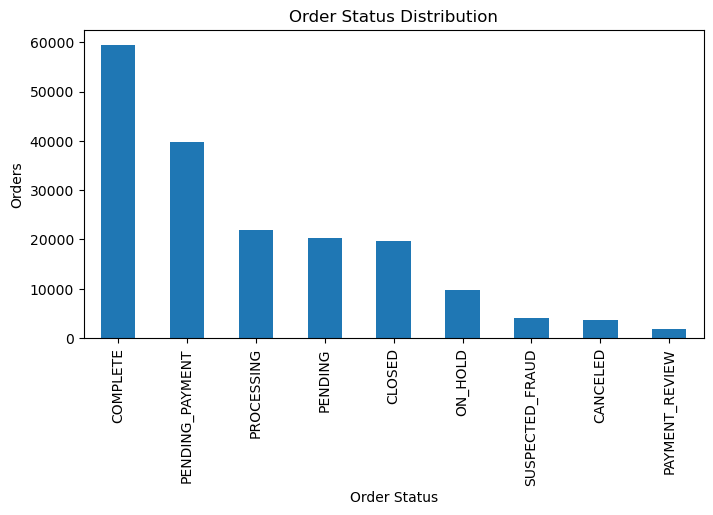

In [79]:
status.plot(kind="bar", figsize=(8,4))
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Orders")
plt.show()

In [ ]:
# ### Output Interpretation

# Order Status represents the business workflow of each transaction.

# Studying its distribution helps understand how many orders are completed, canceled, pending, processing, or flagged for fraud.

In [80]:
# Delivery Status Distribution
delivery = orders["Delivery Status"].value_counts()

delivery

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

In [81]:
(delivery/len(orders)*100).round(2)

Delivery Status
Late delivery        54.83
Advance shipping     23.04
Shipping on time     17.84
Shipping canceled     4.30
Name: count, dtype: float64

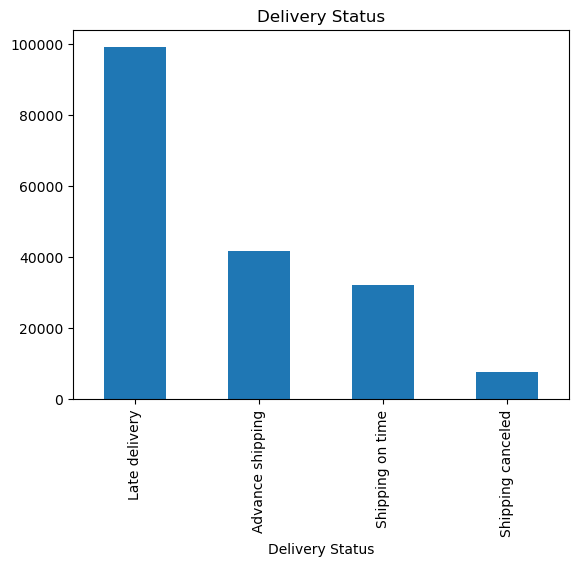

In [82]:
delivery.plot(kind="bar")
plt.title("Delivery Status")
plt.show()

In [ ]:
# ### Output Interpretation

# Delivery Status reflects logistics performance after an order has entered the fulfillment pipeline.

# This field is fundamental for evaluating delivery efficiency.

In [83]:
# Payment Type Distribution
payment = orders["Type"].value_counts()

payment

Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

In [84]:
(payment/len(orders)*100).round(2)

Type
DEBIT       38.39
TRANSFER    27.63
PAYMENT     23.11
CASH        10.87
Name: count, dtype: float64

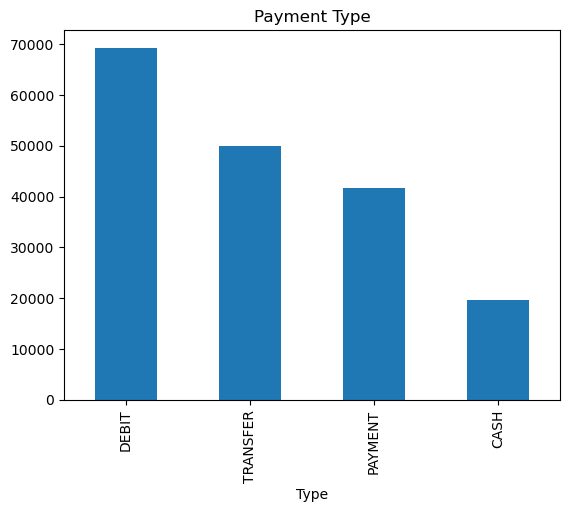

In [85]:
payment.plot(kind="bar")
plt.title("Payment Type")
plt.show()

In [86]:
# ### Output Interpretation

# Payment Type shows the distribution of payment methods used by customers.

# This information is valuable for understanding customer payment preferences and identifying dominant transaction channels.

SyntaxError: invalid syntax (3172092277.py, line 3)

In [87]:
# Shipping Mode Distribution
shipping = orders["Shipping Mode"].value_counts()

shipping

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

In [88]:
(shipping/len(orders)*100).round(2)

Shipping Mode
Standard Class    59.69
Second Class      19.51
First Class       15.41
Same Day           5.39
Name: count, dtype: float64

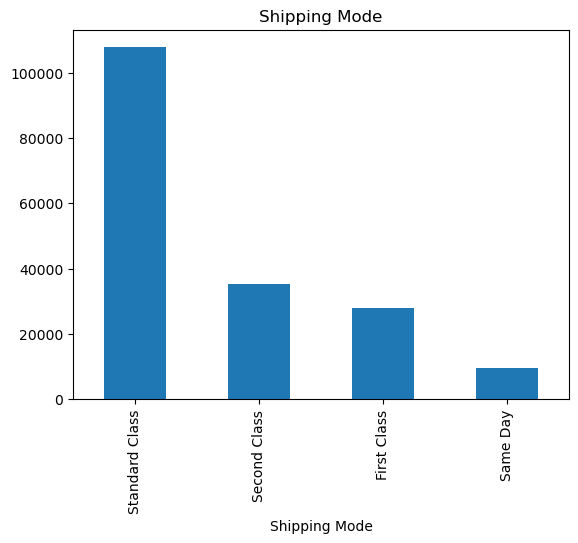

In [89]:
shipping.plot(kind="bar")
plt.title("Shipping Mode")
plt.show()

In [ ]:
# ### Output Interpretation

# Shipping Mode describes the logistics service selected for delivery.

# Differences in shipping mode may later explain variations in delivery performance.

In [90]:
# Order Timeline Investigation
orders[
    [
        "order date (DateOrders)",
        "shipping date (DateOrders)"
    ]
].head()



,order date (DateOrders),shipping date (DateOrders)
0,1/31/2018 22:56,2/3/2018 22:56
1,1/13/2018 12:27,1/18/2018 12:27
2,1/13/2018 12:06,1/17/2018 12:06
3,1/13/2018 11:45,1/16/2018 11:45
4,1/13/2018 11:24,1/15/2018 11:24


In [92]:
orders["order date (DateOrders)"] = pd.to_datetime(
    orders["order date (DateOrders)"]
)

orders["shipping date (DateOrders)"] = pd.to_datetime(
    orders["shipping date (DateOrders)"]
)

In [93]:
orders["order date (DateOrders)"].min()

orders["order date (DateOrders)"].max()

Timestamp('2018-01-31 23:38:00')

In [94]:
orders["shipping date (DateOrders)"].min()

orders["shipping date (DateOrders)"].max()

Timestamp('2018-02-06 22:14:00')

In [ ]:
# ### Output Interpretation

# The date range defines the operational period covered by the dataset and confirms whether sufficient historical information exists for later trend analysis.

In [95]:
order_usefulness = pd.DataFrame({

"Column":[
"Type",
"Order Status",
"Delivery Status",
"Shipping Mode",
"Order Date",
"Shipping Date"
],

"Analytical Usefulness":[
"High",
"High",
"High",
"High",
"High",
"High"
],

"Reason":[
"Customer payment behaviour",
"Order workflow analysis",
"Delivery performance",
"Logistics analysis",
"Time-series analysis",
"Fulfillment analysis"
]

})

order_usefulness

,Column,Analytical Usefulness,Reason
0,Type,High,Customer payment behaviour
1,Order Status,High,Order workflow analysis
2,Delivery Status,High,Delivery performance
3,Shipping Mode,High,Logistics analysis
4,Order Date,High,Time-series analysis
5,Shipping Date,High,Fulfillment analysis


In [ ]:
# ### Order & Fulfillment Investigation Summary

# The Order & Fulfillment domain represents the operational workflow of the business, beginning with payment and ending with product delivery.

# High-value analytical fields include:

# - Payment Type
# - Order Status
# - Delivery Status
# - Shipping Mode
# - Order Date
# - Shipping Date

# These fields form the operational backbone of the dataset and will support later analyses of order processing efficiency, delivery performance, temporal trends, and customer fulfillment experience

# Customer Places Order
#         │
#         ▼
# Payment Type
#         │
#         ▼
# Order Status
#         │
#         ▼
# Shipping Mode
#         │
#         ▼
# Delivery Status
#         │
#         ▼
# Customer Receives Order.

In [ ]:
# # 3. Product Catalog Investigation

# ## Investigation Question

# What products does the company sell, how are they organized into categories and departments, and which product attributes are useful for downstream business analytics?

# ## Why This Matters

# Products are the core assets of the business. Understanding the product catalog helps identify the structure of merchandise, the hierarchy between departments and categories, and which product attributes should be retained for later sales, profitability, and inventory analysis.

In [96]:
# Select Product Columns
product_cols = [
    "Product Name",
    "Category Name",
    "Department Name",
    "Product Image"
]

orders[product_cols].head()

# Reasoning

# These columns describe the merchandise offered by the business rather than customer or operational information.


,Product Name,Category Name,Department Name,Product Image
0,Smart watch,Sporting Goods,Fitness,http://images.acmesports.sports/Smart+watch
1,Smart watch,Sporting Goods,Fitness,http://images.acmesports.sports/Smart+watch
2,Smart watch,Sporting Goods,Fitness,http://images.acmesports.sports/Smart+watch
3,Smart watch,Sporting Goods,Fitness,http://images.acmesports.sports/Smart+watch
4,Smart watch,Sporting Goods,Fitness,http://images.acmesports.sports/Smart+watch


In [97]:
# Inspect Structure
orders[product_cols].info()

### Output Interpretation

# Inspect the data type and completeness of product-related attributes to identify any missing or inconsistent information before further analysis.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Product Name     180519 non-null  object
 1   Category Name    180519 non-null  object
 2   Department Name  180519 non-null  object
 3   Product Image    180519 non-null  object
dtypes: object(4)
memory usage: 5.5+ MB


In [98]:
# Missing Value Check
product_missing = orders[product_cols].isnull().sum().to_frame("Missing Count")
product_missing["Missing %"] = (
    orders[product_cols].isnull().mean() * 100
).round(2)

product_missing

### Output Interpretation

# Missing values within product attributes may reduce the reliability of product-level reporting and category analysis.

,Missing Count,Missing %
Product Name,0,0.0
Category Name,0,0.0
Department Name,0,0.0
Product Image,0,0.0


In [101]:
# Product Cardinality
orders["Product Name"].nunique()

118

In [102]:
orders["Category Name"].nunique()

50

In [103]:
orders["Department Name"].nunique()
### Output Interpretation

# Cardinality measures how many distinct products, categories, and departments exist in the catalog. 
# High cardinality is expected for Product Name, while Category and Department should contain significantly fewer unique values.

11

In [104]:
# Department Distribution
dept_counts = orders["Department Name"].value_counts()

dept_counts

Department Name
Fan Shop              66861
Apparel               48998
Golf                  33220
Footwear              14525
Outdoors               9686
Fitness                2479
Discs Shop             2026
Technology             1465
Pet Shop                492
Book Shop               405
Health and Beauty       362
Name: count, dtype: int64

In [105]:
dept_counts = orders["Department Name"].value_counts()

dept_counts

Department Name
Fan Shop              66861
Apparel               48998
Golf                  33220
Footwear              14525
Outdoors               9686
Fitness                2479
Discs Shop             2026
Technology             1465
Pet Shop                492
Book Shop               405
Health and Beauty       362
Name: count, dtype: int64

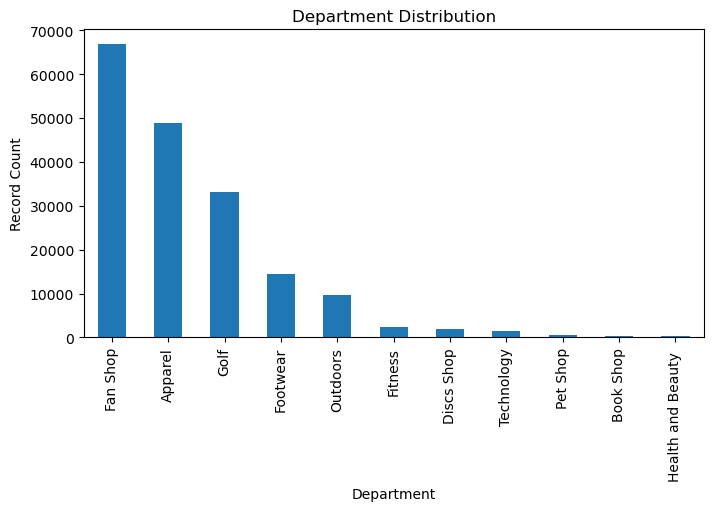

In [106]:
dept_counts.plot(kind="bar", figsize=(8,4))
plt.title("Department Distribution")
plt.xlabel("Department")
plt.ylabel("Record Count")
plt.show()

In [ ]:
# ### Output Interpretation

# Department distribution shows how transaction records are spread across major business divisions. 
# It provides a high-level view of the company's merchandise portfolio.


In [107]:
# Category Distribution
cat_counts = orders["Category Name"].value_counts()

cat_counts

Category Name
Cleats                  24551
Men's Footwear          22246
Women's Apparel         21035
Indoor/Outdoor Games    19298
Fishing                 17325
Water Sports            15540
Camping & Hiking        13729
Cardio Equipment        12487
Shop By Sport           10984
Electronics              3156
Accessories              1780
Golf Balls               1475
Girls' Apparel           1201
Golf Gloves              1070
Trade-In                  974
Video Games               838
Children's Clothing       652
Women's Clothing          650
Baseball & Softball       632
Hockey                    614
Cameras                   592
Toys                      529
Golf Shoes                524
Pet Supplies              492
Garden                    484
Crafts                    484
DVDs                      483
Computers                 442
Golf Apparel              441
Hunting & Shooting        440
Music                     434
Consumer Electronics      431
Boxing & MMA              

In [108]:
(cat_counts / len(orders) * 100).round(2)

Category Name
Cleats                  13.60
Men's Footwear          12.32
Women's Apparel         11.65
Indoor/Outdoor Games    10.69
Fishing                  9.60
Water Sports             8.61
Camping & Hiking         7.61
Cardio Equipment         6.92
Shop By Sport            6.08
Electronics              1.75
Accessories              0.99
Golf Balls               0.82
Girls' Apparel           0.67
Golf Gloves              0.59
Trade-In                 0.54
Video Games              0.46
Children's Clothing      0.36
Women's Clothing         0.36
Baseball & Softball      0.35
Hockey                   0.34
Cameras                  0.33
Toys                     0.29
Golf Shoes               0.29
Pet Supplies             0.27
Garden                   0.27
Crafts                   0.27
DVDs                     0.27
Computers                0.24
Golf Apparel             0.24
Hunting & Shooting       0.24
Music                    0.24
Consumer Electronics     0.24
Boxing & MMA             0

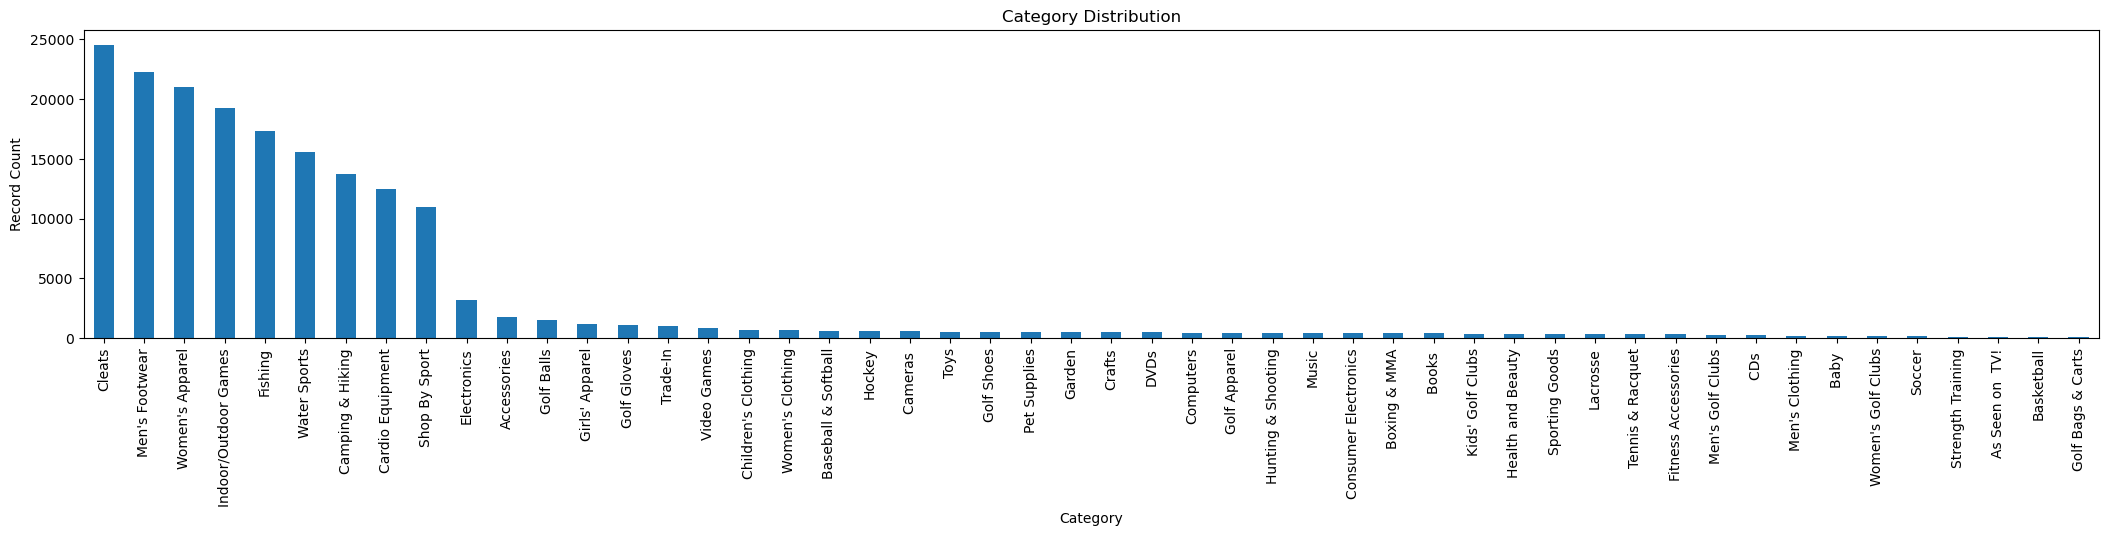

In [119]:
cat_counts.plot(kind="bar", figsize=(26,4))
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Record Count")
plt.show()

In [ ]:
# ### Output Interpretation

# Categories provide a finer level of classification than departments. Their distribution helps identify which product groups dominate the catalog.

In [120]:
# Product Frequency
orders["Product Name"].value_counts().head(15)

Product Name
Perfect Fitness Perfect Rip Deck                 24515
Nike Men's CJ Elite 2 TD Football Cleat          22246
Nike Men's Dri-FIT Victory Golf Polo             21035
O'Brien Men's Neoprene Life Vest                 19298
Field & Stream Sportsman 16 Gun Fire Safe        17325
Pelican Sunstream 100 Kayak                      15500
Diamondback Women's Serene Classic Comfort Bi    13729
Nike Men's Free 5.0+ Running Shoe                12169
Under Armour Girls' Toddler Spine Surge Runni    10617
Fighting video games                               838
Children's heaters                                 652
Summer dresses                                     650
Web Camera                                         592
Toys                                               529
Adult dog supplies                                 492
Name: count, dtype: int64

In [121]:
# Product Image Review
orders["Product Image"].head()

0    http://images.acmesports.sports/Smart+watch 
1    http://images.acmesports.sports/Smart+watch 
2    http://images.acmesports.sports/Smart+watch 
3    http://images.acmesports.sports/Smart+watch 
4    http://images.acmesports.sports/Smart+watch 
Name: Product Image, dtype: object

In [122]:
orders["Product Image"].isnull().sum()
### Output Interpretation

# The Product Image field contains product image URLs rather than analytical information. 
# It has little value for statistical analysis or dashboard reporting and is therefore a candidate for exclusion from the analytical dataset.

np.int64(0)

In [123]:
# Analytical Usefulness Classification
product_usefulness = pd.DataFrame({
    "Column": [
        "Product Name",
        "Category Name",
        "Department Name",
        "Product Image"
    ],
    "Analytical Usefulness": [
        "High",
        "High",
        "High",
        "Low"
    ],
    "Reason": [
        "Identifies individual products for product-level analysis.",
        "Supports category-level aggregation and reporting.",
        "Supports department-level business analysis.",
        "Contains image URL with limited analytical value."
    ]
})

product_usefulness

,Column,Analytical Usefulness,Reason
0,Product Name,High,Identifies individual products for product-lev...
1,Category Name,High,Supports category-level aggregation and report...
2,Department Name,High,Supports department-level business analysis.
3,Product Image,Low,Contains image URL with limited analytical value.


In [ ]:
# ### Product Catalog Investigation Summary

# The product domain defines the merchandise hierarchy of the business.

# High-value analytical fields:
# - Product Name
# - Category Name
# - Department Name

# Low-value analytical field:
# - Product Image

# Department and Category provide hierarchical grouping for products and will support later analyses such as sales performance,
# profitability by product category, and inventory reporting. 
# Product Image contains reference URLs and is not required for downstream analytical workflows.

In [124]:
pd.crosstab(
    orders["Department Name"],
    orders["Category Name"]
)

Category Name,Accessories,As Seen on TV!,Baby,Baseball & Softball,Basketball,Books,Boxing & MMA,CDs,Cameras,Camping & Hiking,...,Sporting Goods,Strength Training,Tennis & Racquet,Toys,Trade-In,Video Games,Water Sports,Women's Apparel,Women's Clothing,Women's Golf Clubs
Department Name,,,,,,,,,,,,,,,,,,,,,
Apparel,0,0,207,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,650,0
Book Shop,0,0,0,0,0,405,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Discs Shop,0,0,0,0,0,0,0,271,0,0,...,0,0,0,0,0,838,0,0,0,0
Fan Shop,0,0,0,0,0,0,0,0,0,13729,...,0,0,0,529,0,0,15540,0,0,0
Fitness,0,0,0,632,67,0,0,0,0,0,...,357,0,328,0,0,0,0,0,0,0
Footwear,0,68,0,0,0,0,423,0,0,0,...,0,111,0,0,0,0,0,0,0,0
Golf,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,21035,0,0
Health and Beauty,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Outdoors,1780,0,0,0,0,0,0,0,0,0,...,0,0,0,0,974,0,0,0,0,181


In [125]:
# Geographic & Market Investigation 
# 4. Geographic & Market Investigation

## Investigation Question

# Where does the company operate, how is its business distributed across markets and geographic regions, 
# and which location-related attributes are valuable for downstream analytical reporting?

## Why This Matters

# The supply chain spans multiple countries and regions. Geographic attributes enable analysts to evaluate market performance, regional demand, delivery efficiency, and operational differences across locations. 
# Understanding these fields is essential before performing regional sales, logistics, or customer analyses.


# Select Geographic Columns
geo_cols = [
    "Market",
    "Order Region",
    "Order Country",
    "Order State",
    "Order City",
    "Customer Country",
    "Customer State",
    "Customer City"
]

orders[geo_cols].head()

### Output Interpretation

# These columns represent the geographical dimensions of both customers and order destinations.
# They will later support market analysis, regional performance evaluation, and logistics reporting.

,Market,Order Region,Order Country,Order State,Order City,Customer Country,Customer State,Customer City
0,Pacific Asia,Southeast Asia,Indonesia,Java Occidental,Bekasi,Puerto Rico,PR,Caguas
1,Pacific Asia,South Asia,India,Rajastán,Bikaner,Puerto Rico,PR,Caguas
2,Pacific Asia,South Asia,India,Rajastán,Bikaner,EE. UU.,CA,San Jose
3,Pacific Asia,Oceania,Australia,Queensland,Townsville,EE. UU.,CA,Los Angeles
4,Pacific Asia,Oceania,Australia,Queensland,Townsville,Puerto Rico,PR,Caguas


In [126]:
# Inspect Structure

orders[geo_cols].info()

### Output Interpretation

# Inspect the data types and completeness of all geographic fields before performing location-based analysis.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Market            180519 non-null  object
 1   Order Region      180519 non-null  object
 2   Order Country     180519 non-null  object
 3   Order State       180519 non-null  object
 4   Order City        180519 non-null  object
 5   Customer Country  180519 non-null  object
 6   Customer State    180519 non-null  object
 7   Customer City     180519 non-null  object
dtypes: object(8)
memory usage: 11.0+ MB


In [127]:
# Missing Values
geo_missing = orders[geo_cols].isnull().sum().to_frame("Missing Count")

geo_missing["Missing %"] = (
    orders[geo_cols].isnull().mean()*100
).round(2)

geo_missing

### Output Interpretation

# Missing geographic information may reduce the accuracy of regional reporting, customer segmentation, and market-level business analysis.

,Missing Count,Missing %
Market,0,0.0
Order Region,0,0.0
Order Country,0,0.0
Order State,0,0.0
Order City,0,0.0
Customer Country,0,0.0
Customer State,0,0.0
Customer City,0,0.0


In [128]:
# Market Distribution
market_counts = orders["Market"].value_counts()

market_counts

Market
LATAM           51594
Europe          50252
Pacific Asia    41260
USCA            25799
Africa          11614
Name: count, dtype: int64

In [129]:
(market_counts / len(orders) * 100).round(2)

Market
LATAM           28.58
Europe          27.84
Pacific Asia    22.86
USCA            14.29
Africa           6.43
Name: count, dtype: float64

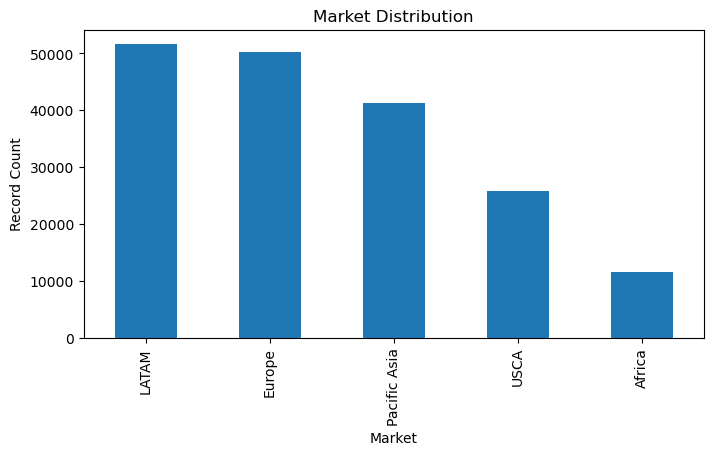

In [130]:
market_counts.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Market Distribution")
plt.xlabel("Market")
plt.ylabel("Record Count")
plt.show()

In [ ]:
### Output Interpretation

# Market represents the highest geographical business level. 
# Its distribution illustrates where the company generates the largest share of transaction records across global markets.

In [131]:
# Order Region Distribution
region_counts = orders["Order Region"].value_counts()

region_counts

Order Region
Central America    28341
Western Europe     27109
South America      14935
Oceania            10148
Northern Europe     9792
Southeast Asia      9539
Southern Europe     9431
Caribbean           8318
West of USA         7993
South Asia          7731
Eastern Asia        7280
East of USA         6915
West Asia           6009
US Center           5887
South of  USA       4045
Eastern Europe      3920
West Africa         3696
North Africa        3232
East Africa         1852
Central Africa      1677
Southern Africa     1157
Canada               959
Central Asia         553
Name: count, dtype: int64

In [132]:
(region_counts / len(orders)*100).round(2)

Order Region
Central America    15.70
Western Europe     15.02
South America       8.27
Oceania             5.62
Northern Europe     5.42
Southeast Asia      5.28
Southern Europe     5.22
Caribbean           4.61
West of USA         4.43
South Asia          4.28
Eastern Asia        4.03
East of USA         3.83
West Asia           3.33
US Center           3.26
South of  USA       2.24
Eastern Europe      2.17
West Africa         2.05
North Africa        1.79
East Africa         1.03
Central Africa      0.93
Southern Africa     0.64
Canada              0.53
Central Asia        0.31
Name: count, dtype: float64

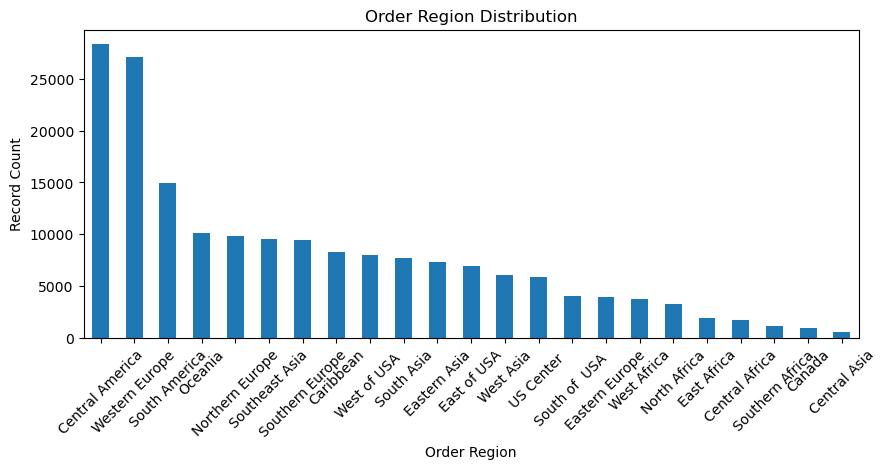

In [133]:
region_counts.plot(
    kind="bar",
    figsize=(10,4)
)

plt.title("Order Region Distribution")
plt.xlabel("Order Region")
plt.ylabel("Record Count")
plt.xticks(rotation=45)

plt.show()

In [ ]:
### Output Interpretation

# Order Region provides a finer geographic breakdown within each market and is useful for regional logistics and operational analysis.

In [134]:
# Customer Country Distribution
orders["Customer Country"].value_counts().head(15)

Customer Country
EE. UU.        111146
Puerto Rico     69373
Name: count, dtype: int64

In [135]:
(
orders["Customer Country"]
.value_counts(normalize=True)
.head(15)*100
).round(2)

### Output Interpretation

# Customer Country identifies where customers originate. 
# This information supports customer distribution analysis and international market evaluation.

Customer Country
EE. UU.        61.57
Puerto Rico    38.43
Name: proportion, dtype: float64

In [136]:
# Order Country Distribution
orders["Order Country"].value_counts().head(15)

Order Country
Estados Unidos          24840
Francia                 13222
México                  13172
Alemania                 9564
Australia                8497
Brasil                   7987
Reino Unido              7302
China                    5758
Italia                   4989
India                    4783
Indonesia                4204
España                   3868
El Salvador              3726
República Dominicana     3669
Honduras                 3629
Name: count, dtype: int64

In [137]:
(
orders["Order Country"]
.value_counts(normalize=True)
.head(15)*100
).round(2)

### Output Interpretation

# Order Country represents the delivery destination rather than the customer's origin.
# Comparing customer and order locations can reveal cross-border purchasing behavior.

Order Country
Estados Unidos          13.76
Francia                  7.32
México                   7.30
Alemania                 5.30
Australia                4.71
Brasil                   4.42
Reino Unido              4.05
China                    3.19
Italia                   2.76
India                    2.65
Indonesia                2.33
España                   2.14
El Salvador              2.06
República Dominicana     2.03
Honduras                 2.01
Name: proportion, dtype: float64

In [139]:
# Geographic Cardinality

orders[
[
"Market",
"Order Region",
"Order Country",
"Order State",
"Order City"
]
].nunique()

### Output Interpretation

# Cardinality indicates the diversity of geographic coverage. Higher cardinality is expected as the hierarchy moves from Market toward individual cities.

Market              5
Order Region       23
Order Country     164
Order State      1089
Order City       3597
dtype: int64

In [140]:
# Customer vs Order Geography
orders[
[
"Customer Country",
"Order Country"
]
].head()

,Customer Country,Order Country
0,Puerto Rico,Indonesia
1,Puerto Rico,India
2,EE. UU.,India
3,EE. UU.,Australia
4,Puerto Rico,Australia


In [141]:
(
orders["Customer Country"]
!=
orders["Order Country"]
).sum()

### Output Interpretation

# This comparison evaluates whether customers typically receive deliveries within their own country or whether international shipping occurs frequently.

np.int64(180519)

In [142]:
# Analytical Usefulness Classification
geo_usefulness = pd.DataFrame({

"Column":[
"Market",
"Order Region",
"Order Country",
"Order State",
"Order City",
"Customer Country",
"Customer State",
"Customer City"
],

"Analytical Usefulness":[
"High",
"High",
"High",
"Medium",
"Medium",
"High",
"Medium",
"Medium"
],

"Reason":[
"Supports market-level business reporting.",
"Supports regional logistics analysis.",
"Supports country-level delivery analysis.",
"Supports state-level geographic reporting.",
"Supports city-level geographic reporting.",
"Supports customer market segmentation.",
"Useful for customer location analysis.",
"Useful for customer location analysis."
]

})

geo_usefulness

,Column,Analytical Usefulness,Reason
0,Market,High,Supports market-level business reporting.
1,Order Region,High,Supports regional logistics analysis.
2,Order Country,High,Supports country-level delivery analysis.
3,Order State,Medium,Supports state-level geographic reporting.
4,Order City,Medium,Supports city-level geographic reporting.
5,Customer Country,High,Supports customer market segmentation.
6,Customer State,Medium,Useful for customer location analysis.
7,Customer City,Medium,Useful for customer location analysis.


In [ ]:
# ### Geographic & Market Investigation Summary

# The dataset contains a well-defined geographic hierarchy covering markets, regions, countries, states, and cities.

# High-value analytical fields include:
# - Market
# - Order Region
# - Order Country
# - Customer Country

# Medium-value analytical fields include:
# - Order State
# - Order City
# - Customer State
# - Customer City

# These attributes will support downstream analyses such as regional sales performance, delivery efficiency, customer distribution, and market-level business reporting.

In [143]:
pd.crosstab(
    orders["Market"],
    orders["Order Region"]
)

Order Region,Canada,Caribbean,Central Africa,Central America,Central Asia,East Africa,East of USA,Eastern Asia,Eastern Europe,North Africa,...,South Asia,South of USA,Southeast Asia,Southern Africa,Southern Europe,US Center,West Africa,West Asia,West of USA,Western Europe
Market,,,,,,,,,,,,,,,,,,,,,
Africa,0,0,1677,0,0,1852,0,0,0,3232,...,0,0,0,1157,0,0,3696,0,0,0
Europe,0,0,0,0,0,0,0,0,3920,0,...,0,0,0,0,9431,0,0,0,0,27109
LATAM,0,8318,0,28341,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Pacific Asia,0,0,0,0,553,0,0,7280,0,0,...,7731,0,9539,0,0,0,0,6009,0,0
USCA,959,0,0,0,0,0,6915,0,0,0,...,0,4045,0,0,0,5887,0,0,7993,0


In [144]:
pd.crosstab(
    orders["Order Country"],
    orders["Order Region"]
)

Order Region,Canada,Caribbean,Central Africa,Central America,Central Asia,East Africa,East of USA,Eastern Asia,Eastern Europe,North Africa,...,South Asia,South of USA,Southeast Asia,Southern Africa,Southern Europe,US Center,West Africa,West Asia,West of USA,Western Europe
Order Country,,,,,,,,,,,,,,,,,,,,,
Afganistán,0,0,0,0,0,0,0,0,0,0,...,163,0,0,0,0,0,0,0,0,0
Albania,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,37,0,0,0,0,0
Alemania,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9564
Angola,0,0,306,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Arabia Saudí,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,860,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vietnam,0,0,0,0,0,0,0,0,0,0,...,0,0,757,0,0,0,0,0,0,0
Yemen,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,71,0,0
Yibuti,0,0,0,0,0,31,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [145]:
pd.crosstab(
    orders["Order State"],
    orders["Order Country"]
)

Order Country,Afganistán,Albania,Alemania,Angola,Arabia Saudí,Argelia,Argentina,Armenia,Australia,Austria,...,Ucrania,Uganda,Uruguay,Uzbekistán,Venezuela,Vietnam,Yemen,Yibuti,Zambia,Zimbabue
Order State,,,,,,,,,,,,,,,,,,,,,
Abia,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Abruzos,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Aceh,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Acre,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Adamaoua,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
iauliai,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ilina,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Çanakkale,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# 16. Website Clickstream Investigation

## Investigation Question

# What information does the website clickstream dataset contain, and which attributes are valuable for understanding customer browsing behavior before purchase?

## Why This Matters

# Unlike the transactional dataset, the clickstream dataset records customer interactions with the website before or during the purchasing journey. Profiling these fields helps assess browsing activity, navigation patterns, product visibility, and potential behavioral insights for future analysis.

In [147]:
# Preview Dataset
clickstreams.head()
### Output Interpretation

# Review the structure of the clickstream dataset and understand what type of browsing events are recorded.

,Product,Category,Date,Month,Hour,Department,ip,url
0,adidas Brazuca 2017 Official Match Ball,baseball & softball,9/1/2017 6:00,Sep,6,fitness,37.97.182.65,/department/fitness/category/baseball%20&%20so...
1,The North Face Women's Recon Backpack,hunting & shooting,9/1/2017 6:00,Sep,6,fan shop,206.56.112.1,/department/fan%20shop/category/hunting%20&%20...
2,adidas Kids' RG III Mid Football Cleat,featured shops,9/1/2017 6:00,Sep,6,apparel,215.143.180.0,/department/apparel/category/featured%20shops/...
3,Under Armour Men's Compression EV SL Slide,electronics,9/1/2017 6:00,Sep,6,footwear,206.56.112.1,/department/footwear/category/electronics/prod...
4,Pelican Sunstream 100 Kayak,water sports,9/1/2017 6:01,Sep,6,fan shop,136.108.56.242,/department/fan%20shop/category/water%20sports...


In [151]:
# Dataset Structure
clickstreams.info()

### Output Interpretation

# Inspect the number of records, data types, and overall completeness of the clickstream dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 469977 entries, 0 to 469976
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Product     469977 non-null  object
 1   Category    469977 non-null  object
 2   Date        469977 non-null  object
 3   Month       469977 non-null  object
 4   Hour        469977 non-null  int64 
 5   Department  469977 non-null  object
 6   ip          469977 non-null  object
 7   url         469977 non-null  object
dtypes: int64(1), object(7)
memory usage: 28.7+ MB


In [153]:
# Missing Values
click_missing = clickstreams.isnull().sum().to_frame("Missing Count")

click_missing["Missing %"] = (
    clickstreams.isnull().mean()*100
).round(2)

click_missing

### Output Interpretation

# Missing values may indicate incomplete browsing events or unavailable website tracking information.

,Missing Count,Missing %
Product,0,0.0
Category,0,0.0
Date,0,0.0
Month,0,0.0
Hour,0,0.0
Department,0,0.0
ip,0,0.0
url,0,0.0


In [155]:
clickstreams.nunique()

Product           76
Category          33
Date          160815
Month              5
Hour              24
Department         6
ip              3340
url              152
dtype: int64

In [157]:
# Product Distribution
clickstreams["Product"].value_counts().head(15)

Product
Perfect Fitness Perfect Rip Deck                 27878
adidas Kids' RG III Mid Football Cleat           26200
Nike Men's Dri-FIT Victory Golf Polo             25627
Nike Men's CJ Elite 2 TD Football Cleat          25241
O'Brien Men's Neoprene Life Vest                 16194
Pelican Sunstream 100 Kayak                      16186
Diamondback Women's Serene Classic Comfort Bi    15521
Field & Stream Sportsman 16 Gun Fire Safe        15178
Under Armour Hustle Storm Medium Duffle Bag      13752
Columbia Men's PFG Anchor Tough T-Shirt          13716
Nike Men's Free 5.0+ Running Shoe                13641
Nike Men's Free TR 5.0 TB Training Shoe          13448
Nike Men's Comfort 2 Slide                       13275
Under Armour Men's Tech II T-Shirt               12676
Under Armour Girls' Toddler Spine Surge Runni    12511
Name: count, dtype: int64

In [159]:
(
clickstreams["Product"]
.value_counts(normalize=True)
.head(15)*100
).round(2)

### Output Interpretation

# Frequently viewed products may indicate higher customer interest or greater product visibility on the website.

Product
Perfect Fitness Perfect Rip Deck                 5.93
adidas Kids' RG III Mid Football Cleat           5.57
Nike Men's Dri-FIT Victory Golf Polo             5.45
Nike Men's CJ Elite 2 TD Football Cleat          5.37
O'Brien Men's Neoprene Life Vest                 3.45
Pelican Sunstream 100 Kayak                      3.44
Diamondback Women's Serene Classic Comfort Bi    3.30
Field & Stream Sportsman 16 Gun Fire Safe        3.23
Under Armour Hustle Storm Medium Duffle Bag      2.93
Columbia Men's PFG Anchor Tough T-Shirt          2.92
Nike Men's Free 5.0+ Running Shoe                2.90
Nike Men's Free TR 5.0 TB Training Shoe          2.86
Nike Men's Comfort 2 Slide                       2.82
Under Armour Men's Tech II T-Shirt               2.70
Under Armour Girls' Toddler Spine Surge Runni    2.66
Name: proportion, dtype: float64

In [161]:
# Category Distribution
clickstreams["Category"].value_counts()

Category
cleats                  27878
shop by sport           26227
featured shops          26200
women's apparel         25627
men's footwear          25241
girls' apparel          24581
electronics             20845
indoor outdoor games    16194
water sports            16186
hunting & shooting      15645
camping & hiking        15521
fishing                 15178
fitness accessories     13752
hockey                  13657
cardio equipment        13641
as seen on  tv!         13448
tennis & racquet        13275
lacrosse                12676
strength training       12479
basketball              12313
soccer                  12271
boxing & mma            12260
baseball & softball     12245
women's golf clubs       7782
golf shoes               7732
golf gloves              7510
golf bags & carts        7438
golf apparel             7427
accessories              7279
kids' golf clubs         7234
trade-in                 7208
golf balls               7063
men's golf clubs         5964
N

In [165]:
clickstreams["Category"].value_counts().plot(
    kind="bar",
    figsize=(10,4)
)

plt.title("Website Category Distribution")
plt.xlabel("Category")
plt.ylabel("Record Count")


plt.show()

### Output Interpretation

# Category distribution highlights which product categories receive the greatest browsing activity.

SyntaxError: invalid syntax (2606215752.py, line 15)

In [167]:
# Department Distribution
clickstreams["Department"].value_counts()

Department
outdoors     79926
apparel      79319
footwear     79136
fan shop     78724
fitness      76437
golf         76435
Name: count, dtype: int64

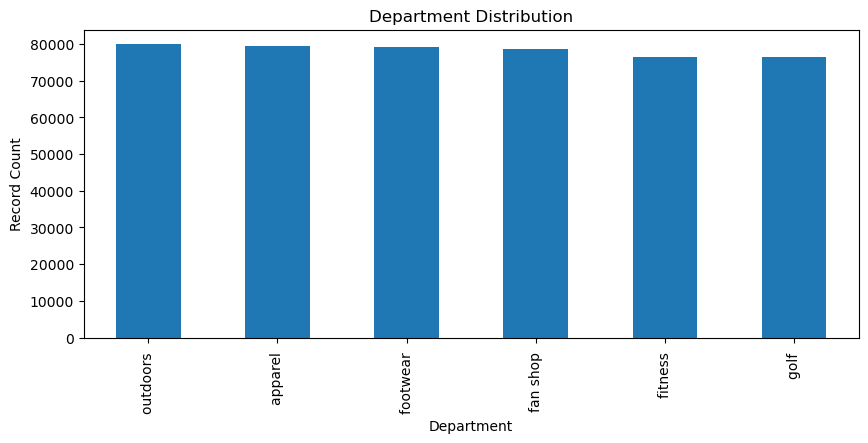

In [169]:
clickstreams["Department"].value_counts().plot(
    kind="bar",
    figsize=(10,4)
)

plt.title("Department Distribution")
plt.xlabel("Department")
plt.ylabel("Record Count")


plt.show()

### Output Interpretation

# Department identifies broader business divisions that receive customer traffic across the website.

In [171]:
# Date Investigation
clickstreams["Date"].head()

0    9/1/2017 6:00
1    9/1/2017 6:00
2    9/1/2017 6:00
3    9/1/2017 6:00
4    9/1/2017 6:01
Name: Date, dtype: object

In [173]:
clickstreams["Date"].dtype

dtype('O')

In [175]:
clickstreams["Date"].min(), clickstreams["Date"].max()

('1/1/2018 10:00', '9/9/2017 9:59')

In [ ]:
### Output Interpretation

# The browsing logs span a defined observation period. Date fields will later support time-series analysis of website traffic.

In [177]:
# IP Address Investigation
clickstreams["ip"].nunique()

3340

In [178]:
clickstreams["ip"].head()

0      37.97.182.65
1      206.56.112.1
2     215.143.180.0
3      206.56.112.1
4    136.108.56.242
Name: ip, dtype: object

In [181]:
# URL Investigation
clickstreams["url"].head()

0    /department/fitness/category/baseball%20&%20so...
1    /department/fan%20shop/category/hunting%20&%20...
2    /department/apparel/category/featured%20shops/...
3    /department/footwear/category/electronics/prod...
4    /department/fan%20shop/category/water%20sports...
Name: url, dtype: object

In [183]:
clickstreams["url"].nunique()
### Output Interpretation

# Website URLs identify the exact pages visited by users and can later support navigation path and product journey analysis.

152

In [184]:
# Analytical Usefulness
click_usefulness = pd.DataFrame({

"Column":[
"Product",
"Category",
"Date",
"Month",
"Department",
"ip",
"url"
],

"Analytical Usefulness":[
"High",
"High",
"High",
"Medium",
"High",
"Medium",
"High"
],

"Reason":[
"Identifies viewed products.",
"Supports browsing analysis.",
"Supports time-based traffic analysis.",
"Useful for aggregation.",
"Supports departmental traffic analysis.",
"Approximates visitor sessions.",
"Supports navigation path analysis."
]

})

click_usefulness

,Column,Analytical Usefulness,Reason
0,Product,High,Identifies viewed products.
1,Category,High,Supports browsing analysis.
2,Date,High,Supports time-based traffic analysis.
3,Month,Medium,Useful for aggregation.
4,Department,High,Supports departmental traffic analysis.
5,ip,Medium,Approximates visitor sessions.
6,url,High,Supports navigation path analysis.


In [ ]:
# ### Website Clickstream Investigation Summary

# The clickstream dataset captures customer browsing behavior across products, categories, departments, and website pages.

# High-value analytical fields include:
# - Product
# - Category
# - Department
# - Date
# - URL

# The IP field provides approximate visitor identification but should not be interpreted as a unique customer identifier.

# This dataset complements the transactional order data by describing customer interactions prior to or during the purchasing process. 
# It provides the behavioral foundation for future analyses such as product popularity, browsing trends, and website navigation patterns.